# 1 - Data Exploration

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## 1.1 Load Data

In [24]:
# Loading our dataset
data = pd.read_csv('covtype.csv')

# Showing the first five rows
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [25]:
data.shape

(581012, 55)

## 1.2 Compress Data

In [26]:
data.dtypes

,0
Elevation,int64
Aspect,int64
Slope,int64
Horizontal_Distance_To_Hydrology,int64
Vertical_Distance_To_Hydrology,int64
Horizontal_Distance_To_Roadways,int64
Hillshade_9am,int64
Hillshade_Noon,int64
Hillshade_3pm,int64
Horizontal_Distance_To_Fire_Points,int64


In [27]:
def compress(df, **kwargs):
    """
    Reduces the size of the DataFrame by downcasting numerical columns
    """
    input_size = df.memory_usage(index=True).sum()/ 1024**2
    print("old dataframe size: ", round(input_size,2), 'MB')

    in_size = df.memory_usage(index=True).sum()

    for t in ["float", "integer"]:
        l_cols = list(df.select_dtypes(include=t))

        for col in l_cols:
            df[col] = pd.to_numeric(df[col], downcast=t)

    out_size = df.memory_usage(index=True).sum()
    ratio = (1 - round(out_size / in_size, 2)) * 100

    print("optimized size by {} %".format(round(ratio,2)))
    print("new DataFrame size: ", round(out_size / 1024**2,2), " MB")

    return df

In [28]:
data = compress(data,verbose = 2)
data.head()

old dataframe size:  243.8 MB
optimized size by 85.0 %
new DataFrame size:  35.46  MB


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## 1.3 Clean Data

In [29]:
duplicate_count = len(data) - len(data.drop_duplicates()) # Original data length minus data length without duplicates
duplicate_count

0

In [30]:
round(data.isnull().sum().sort_values(ascending=False)/len(data),2) #NaN percentage for each column

,0
Elevation,0.0
Soil_Type28,0.0
Soil_Type17,0.0
Soil_Type18,0.0
Soil_Type19,0.0
Soil_Type20,0.0
Soil_Type21,0.0
Soil_Type22,0.0
Soil_Type23,0.0
Soil_Type24,0.0


In [33]:
data = data[data.Elevation > 0]
data = data[data.Horizontal_Distance_To_Hydrology > 0]
data = data[data.Horizontal_Distance_To_Roadways > 0]
data = data[data.Horizontal_Distance_To_Fire_Points > 0]

In [34]:
data.shape

(556246, 55)

## 1.4 Visualize Data

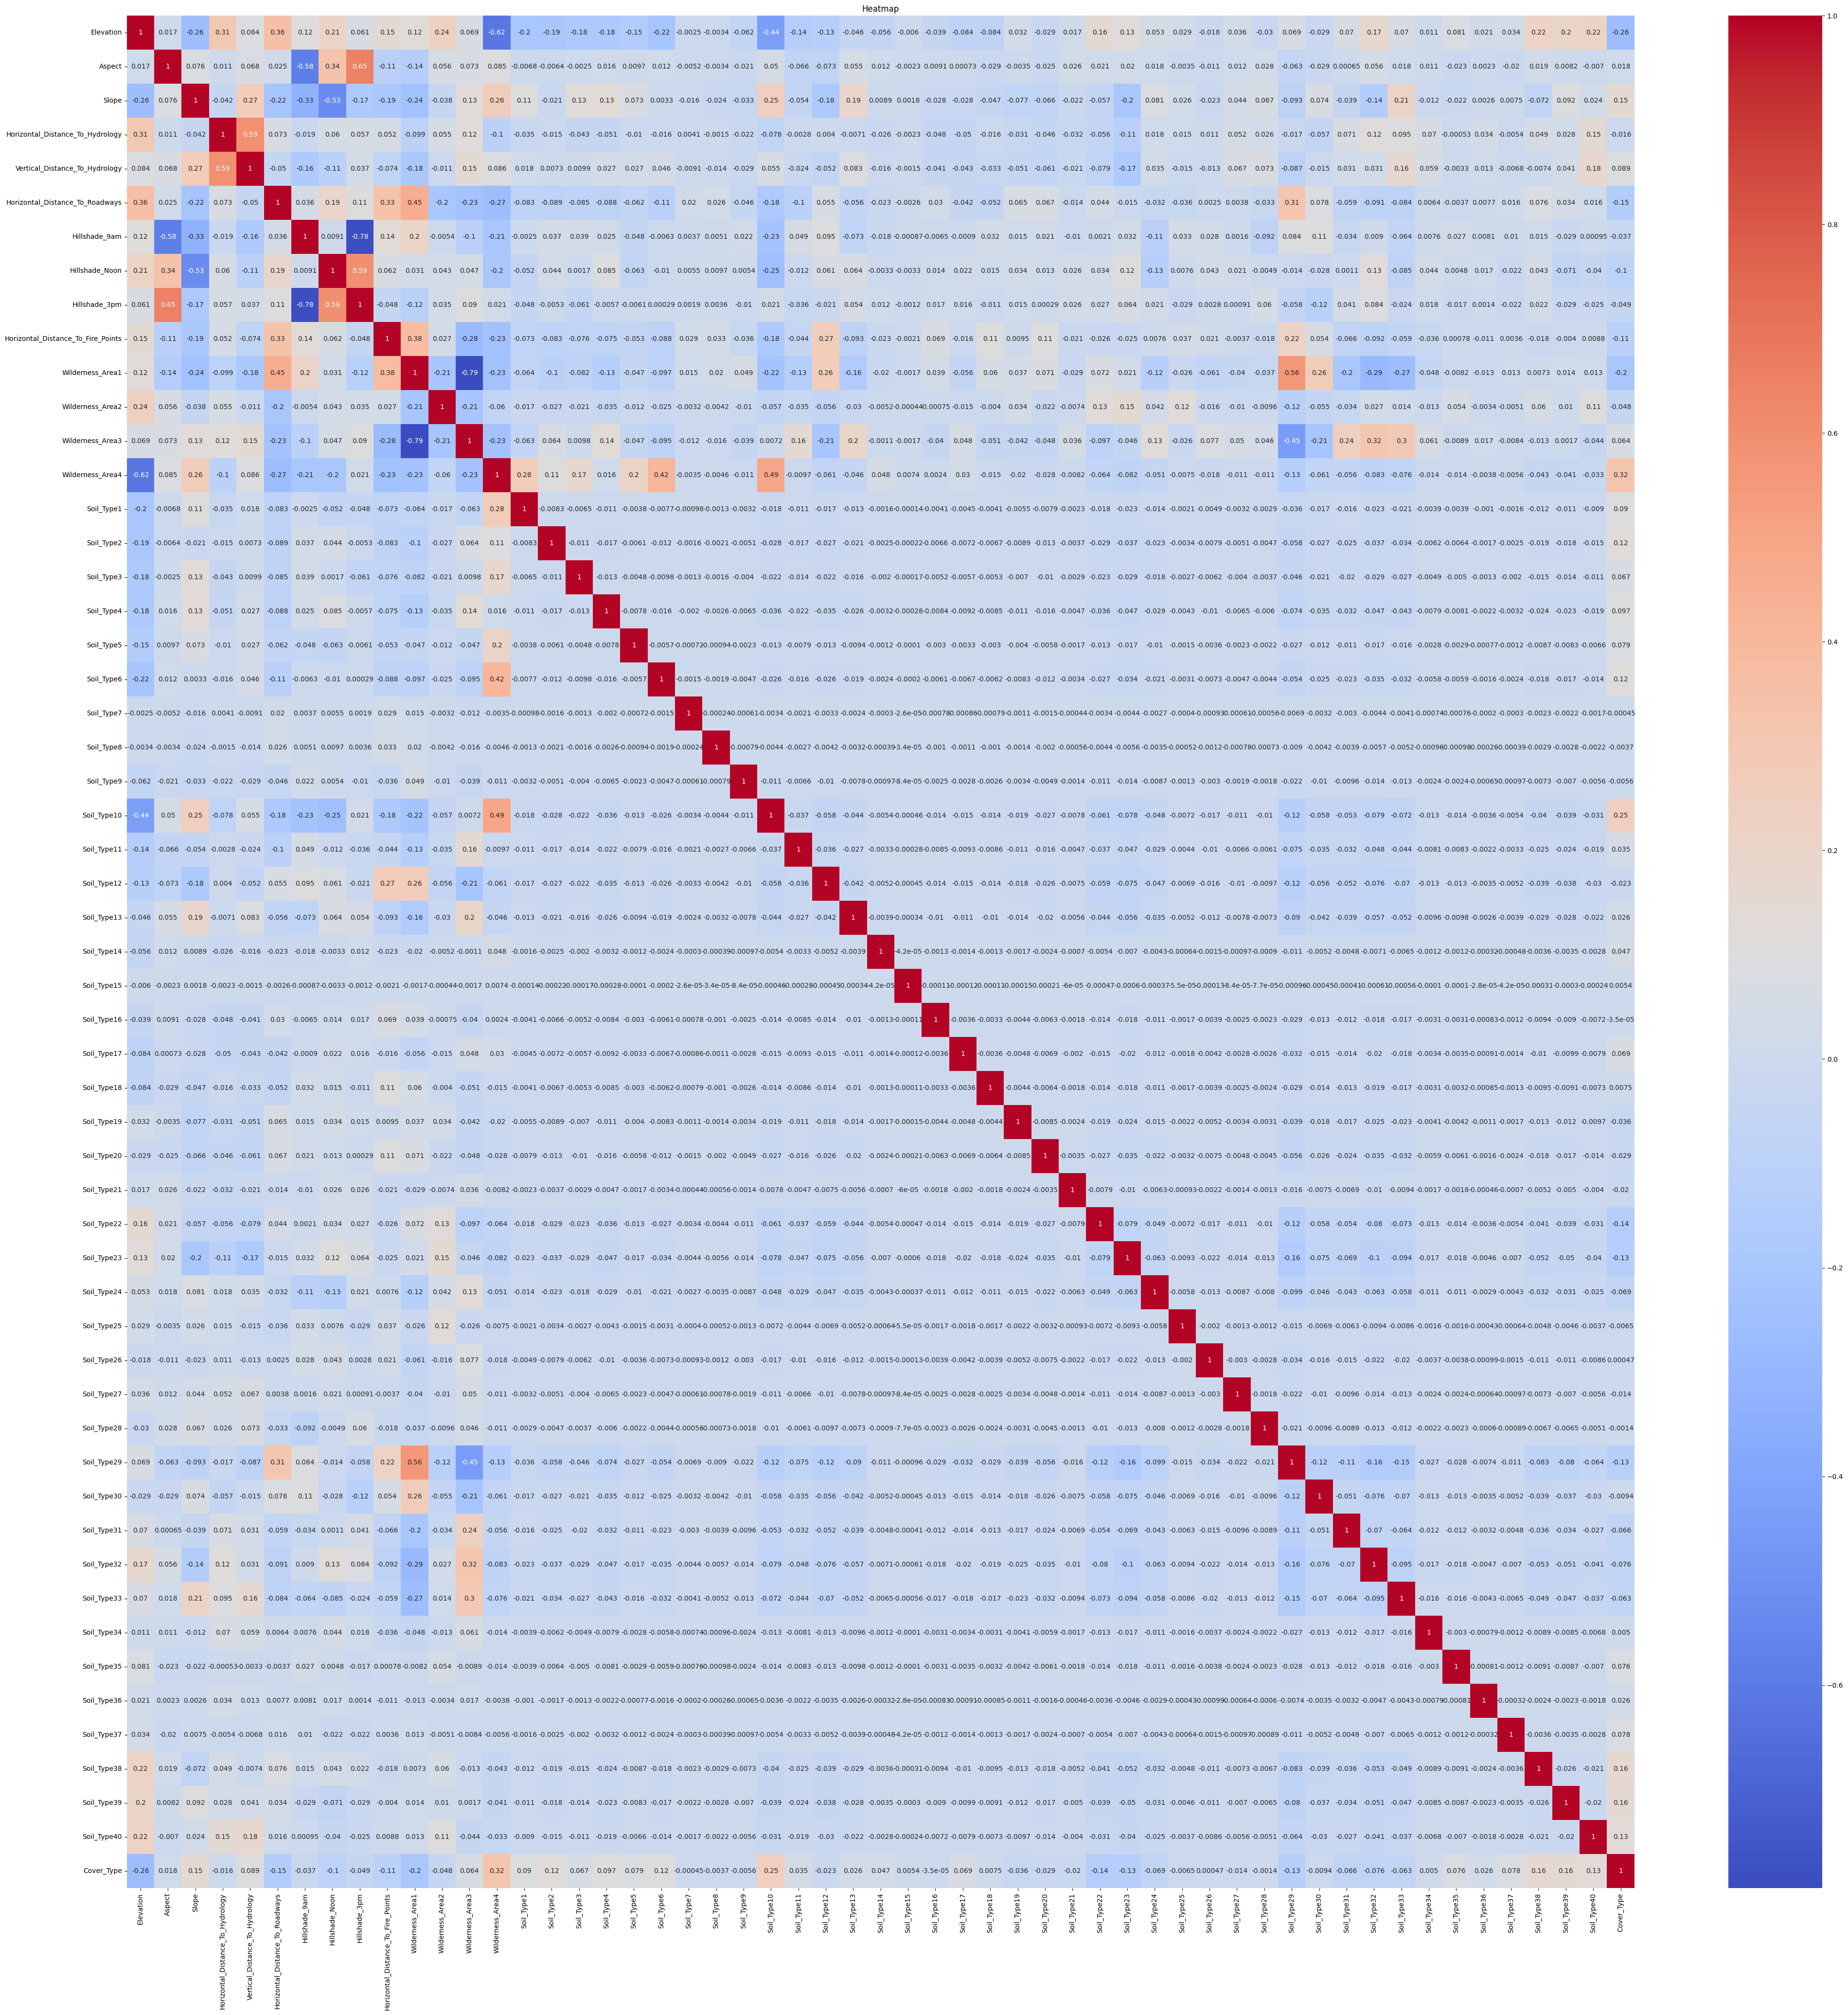

In [40]:
plt.figure(figsize=(50, 50))

corr = data.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Heatmap')
plt.show()

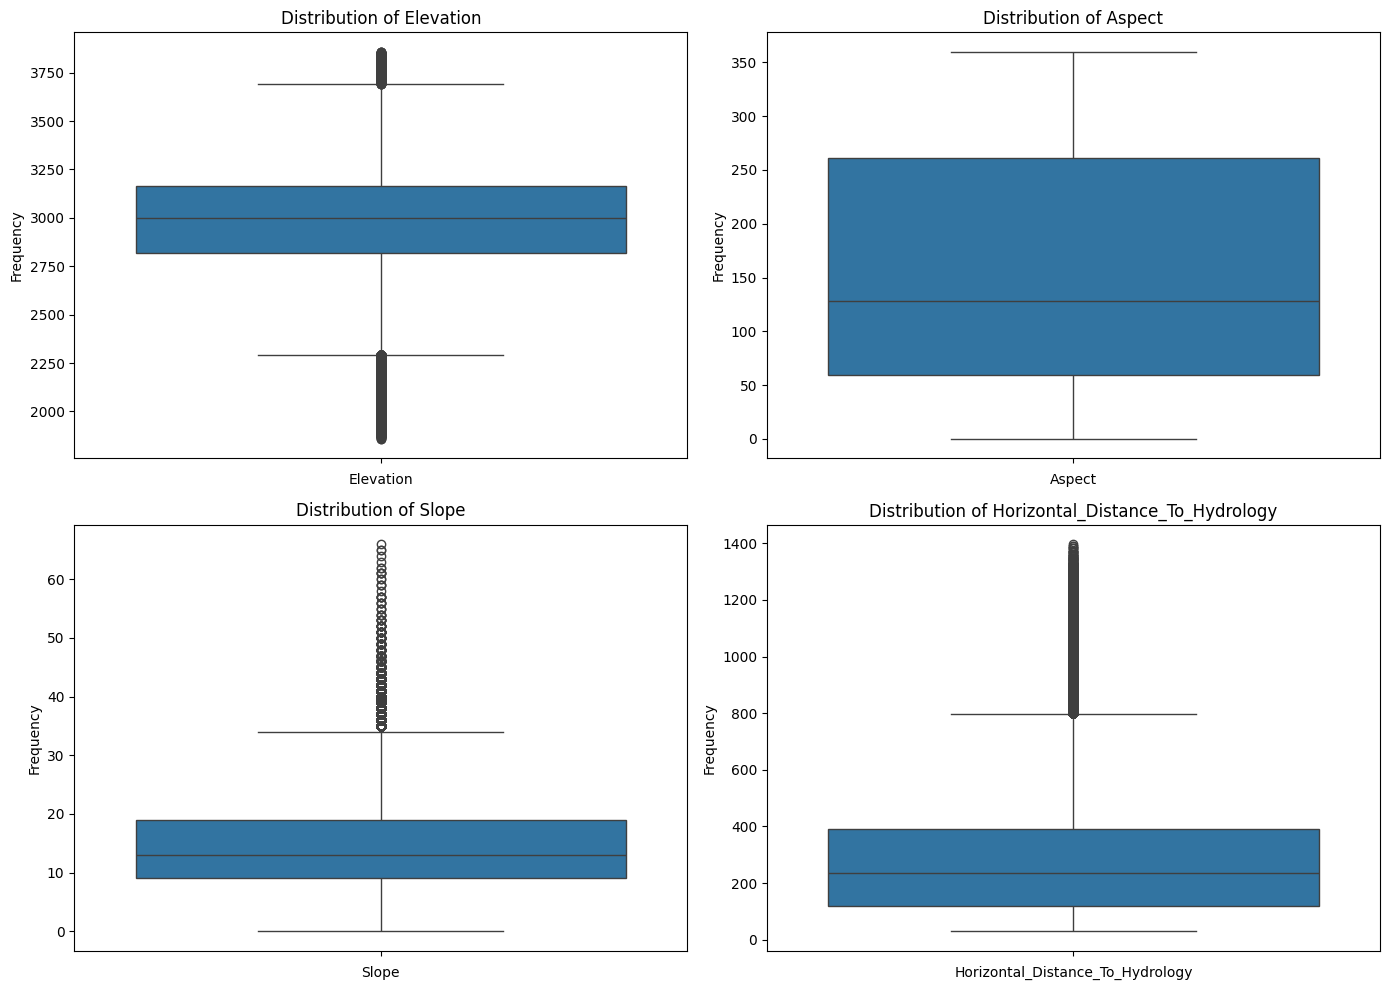

In [44]:
features_to_plot = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology']
plt.figure(figsize=(14, 10))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data[feature])
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

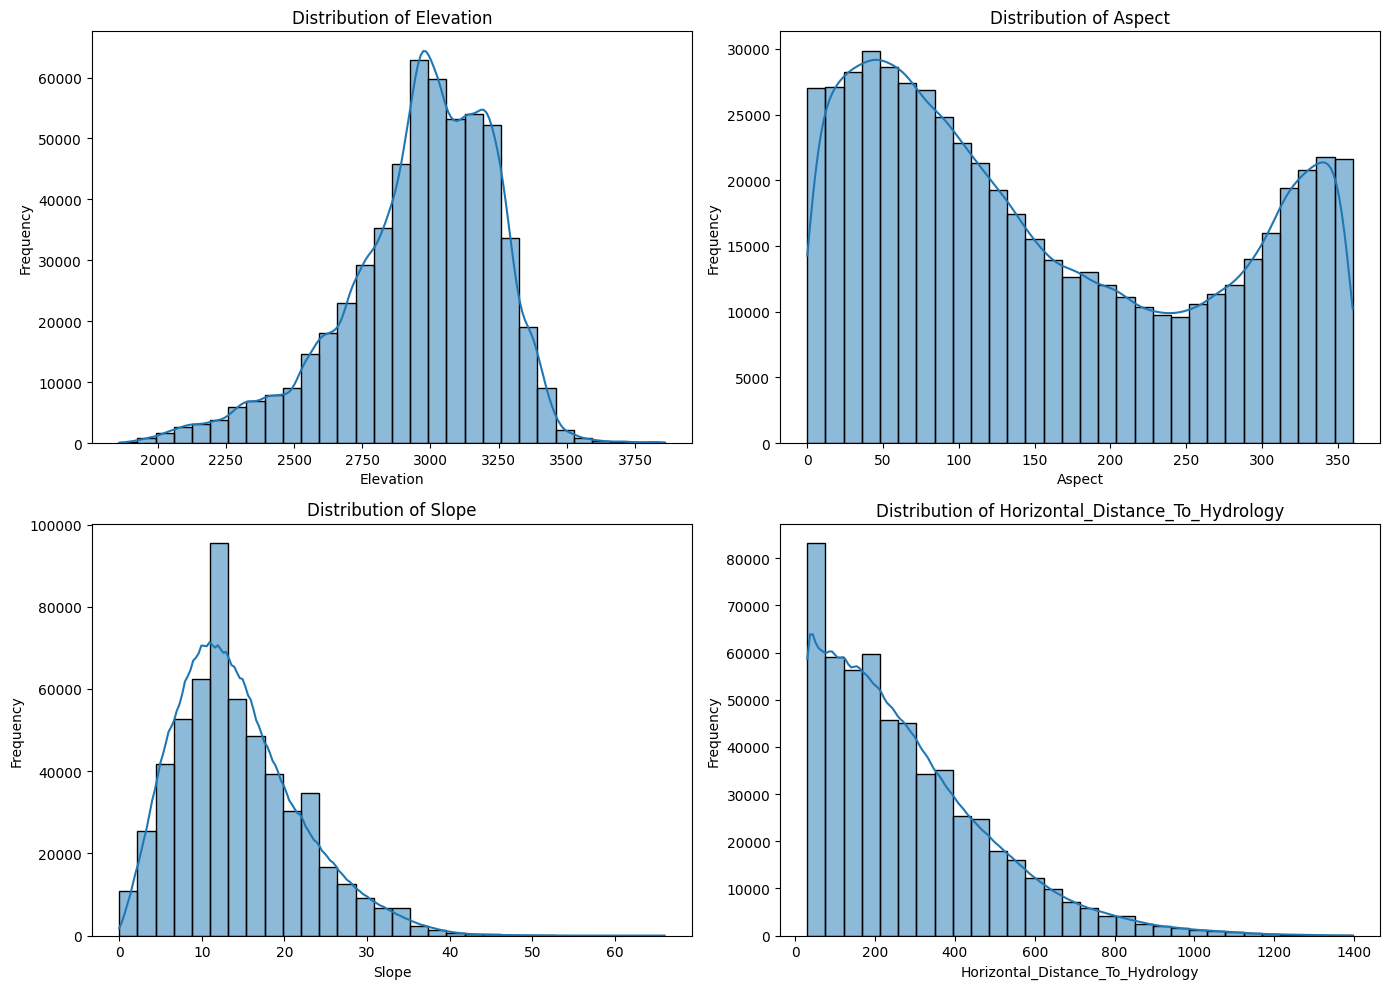

In [42]:
features_to_plot = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology']
plt.figure(figsize=(14, 10))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

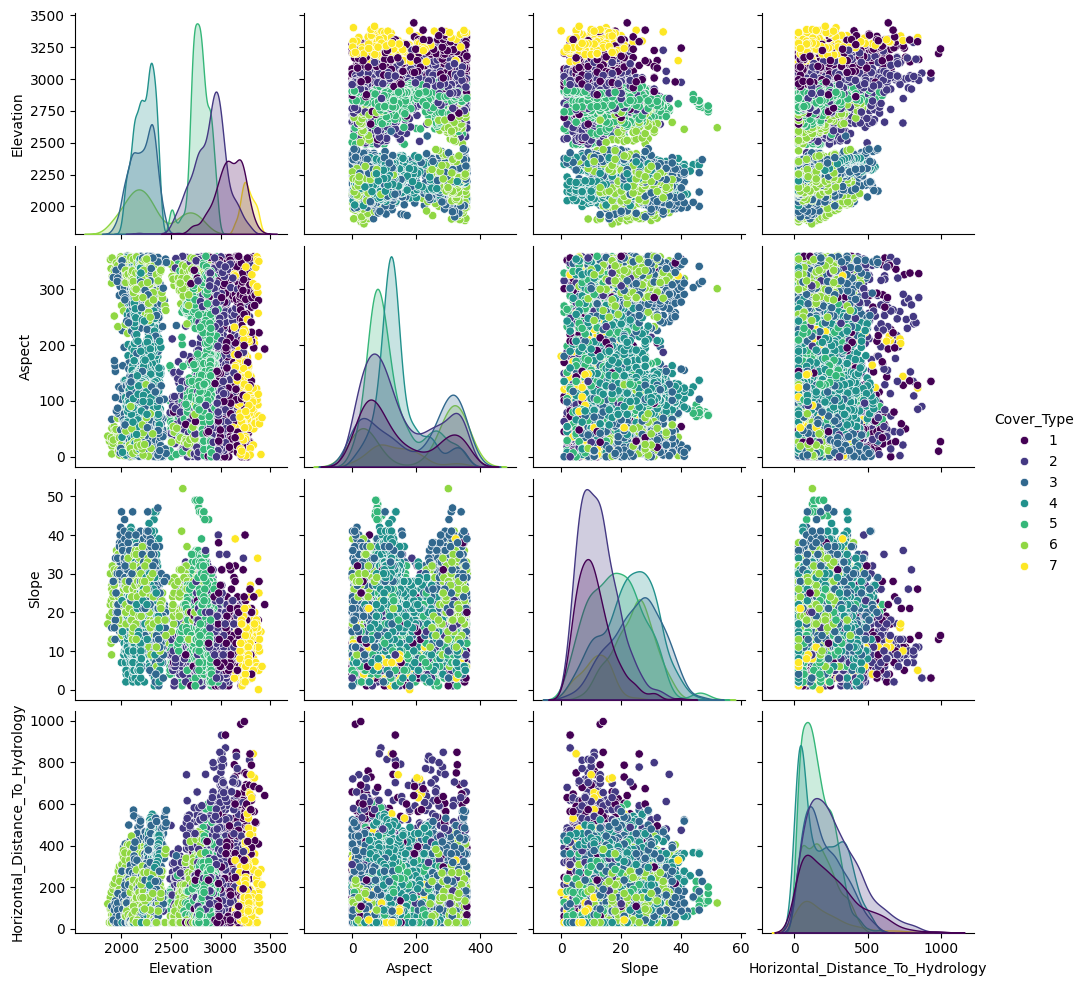

In [43]:
features_to_plot = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Cover_Type']

# you can increse the number of rows
sns.pairplot(data.loc[:5000,features_to_plot], hue='Cover_Type', palette='viridis', diag_kind='kde')

# 2 - Data Pre-Processer

## 2.1 Emouting

In [35]:
duplicate_count = len(data) - len(data.drop_duplicates()) # Original data length minus data length without duplicates
duplicate_count

0

In [36]:
round(data.isnull().sum().sort_values(ascending=False)/len(data),2) #NaN percentage for each column

,0
Elevation,0.0
Soil_Type28,0.0
Soil_Type17,0.0
Soil_Type18,0.0
Soil_Type19,0.0
Soil_Type20,0.0
Soil_Type21,0.0
Soil_Type22,0.0
Soil_Type23,0.0
Soil_Type24,0.0


## 2.2 Scaling

In [37]:
# Split into features (X) and target (y)
X = data.drop('Cover_Type', axis=1)  # Drop the target column 'Cover_Type'
y = data['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state = 42)

In [39]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder


# Initialize scalers
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
label_encoder = LabelEncoder()

# 1. StandardScaler for Elevation
X_train['Elevation'] = standard_scaler.fit_transform(X_train[['Elevation']])
X_test['Elevation'] = standard_scaler.transform(X_test[['Elevation']])

# 2. MinMaxScaler for Aspect
X_train['Aspect'] = min_max_scaler.fit_transform(X_train[['Aspect']])
X_test['Aspect'] = min_max_scaler.transform(X_test[['Aspect']])

# 1. StandardScaler for Elevation
X_train['Slope'] = standard_scaler.fit_transform(X_train[['Slope']])
X_test['Slope'] = standard_scaler.transform(X_test[['Slope']])

# 4. RobustScaler for Horizontal_Distance_To_Hydrology
X_train['Horizontal_Distance_To_Hydrology'] = robust_scaler.fit_transform(X_train[['Horizontal_Distance_To_Hydrology']])
X_test['Horizontal_Distance_To_Hydrology'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Hydrology']])

# 5. RobustScaler for Vertical_Distance_To_Hydrology
X_train['Vertical_Distance_To_Hydrology'] = robust_scaler.fit_transform(X_train[['Vertical_Distance_To_Hydrology']])
X_test['Vertical_Distance_To_Hydrology'] = robust_scaler.transform(X_test[['Vertical_Distance_To_Hydrology']])

# 6. RobustScaler for Horizontal_Distance_To_Roadways
X_train['Horizontal_Distance_To_Roadways'] = robust_scaler.fit_transform(X_train[['Horizontal_Distance_To_Roadways']])
X_test['Horizontal_Distance_To_Roadways'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Roadways']])

# 7. MinMaxScaler for Hillshade_9am, Hillshade_Noon, Hillshade_3pm
X_train['Hillshade_9am'] = min_max_scaler.fit_transform(X_train[['Hillshade_9am']])
X_test['Hillshade_9am'] = min_max_scaler.transform(X_test[['Hillshade_9am']])

X_train['Hillshade_Noon'] = min_max_scaler.fit_transform(X_train[['Hillshade_Noon']])
X_test['Hillshade_Noon'] = min_max_scaler.transform(X_test[['Hillshade_Noon']])

X_train['Hillshade_3pm'] = min_max_scaler.fit_transform(X_train[['Hillshade_3pm']])
X_test['Hillshade_3pm'] = min_max_scaler.transform(X_test[['Hillshade_3pm']])


# 8. RobustScaler for Horizontal_Distance_To_Fire_Points
X_train['Horizontal_Distance_To_Fire_Points'] = robust_scaler.fit_transform(X_train[['Horizontal_Distance_To_Fire_Points']])
X_test['Horizontal_Distance_To_Fire_Points'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Fire_Points']])

In [ ]:
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


# 3 -  Feature Selection

In [ ]:
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
from sklearn.inspection import permutation_importance

# Fit model
log_model = LogisticRegression().fit(X, y)

# Perform the permutation
permutation_score = permutation_importance(log_model, X, y, n_repeats=10)

# Unstack results showing the decrease in performance after shuffling features
importance_df = pd.DataFrame(np.vstack((X.columns,
                                        permutation_score.importances_mean)).T)
importance_df.columns=['feature','score decrease']

# Show the important features
importance_df.sort_values(by="score decrease", ascending = False)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,feature,score decrease
0,Elevation,0.163359
6,Hillshade_9am,0.043991
8,Hillshade_3pm,0.020709
4,Vertical_Distance_To_Hydrology,0.013509
3,Horizontal_Distance_To_Hydrology,0.005621
5,Horizontal_Distance_To_Roadways,0.005286
9,Horizontal_Distance_To_Fire_Points,0.005005
7,Hillshade_Noon,0.004734
2,Slope,0.003076
1,Aspect,0.001127


In [ ]:
# Apply SelectKBest to select top 'k' features
k = 10  # Adjust this value to choose how many features to select
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)

# Get the selected feature names
selected_features = X.columns[selector.get_support()]

# Print the selected features
print("Selected Features using SelectKBest:", selected_features)

Selected Features using SelectKBest: Index(['Elevation', 'Horizontal_Distance_To_Roadways', 'Wilderness_Area1',
       'Wilderness_Area4', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4',
       'Soil_Type10', 'Soil_Type38', 'Soil_Type39'],
      dtype='object')


# 4 - Model Selection

In [ ]:
X_train.shape

(464809, 54)

In [ ]:
model = RandomForestClassifier(n_estimators = 100, max_depth = 10, max_features = 'sqrt', n_jobs = -1)

model.fit(X_train, y_train)

scoring = ['accuracy', 'recall', 'precision']

cv_results = cross_validate(model,
                            X_train,
                            y_train,
                            scoring = scoring,
                            cv = 10)

print(f"Accuracy: {cv_results['test_accuracy']}")
print(f"Recall: {cv_results['test_recall']}")
print(f"Precision: {cv_results['test_precision']}")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py", line 2385, in recall_score
    _, r, _, _ = precision_recall_fscore_support(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_param_validation.py", line 186, in wrapper
    return func(*args, **kwargs)
  File "/usr/local/lib/

Accuracy: [0.74763882 0.75415761 0.74832727 0.75420064 0.74987629 0.75254405
 0.7542867  0.75430821 0.75247951 0.75527108]
Recall: [nan nan nan nan nan nan nan nan nan nan]
Precision: [nan nan nan nan nan nan nan nan nan nan]
Accuracy: 0.7569684087329931
Precision: 0.7070310738008826
Recall: 0.49269919974377474


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_model = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf,
                              cv=5, n_jobs=-1)

grid_search_rf.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)
print("Best Random Forest Score:", grid_search_rf.best_score_)

In [ ]:
X_train_ = X_train[['Elevation', 'Hillshade_9am', 'Hillshade_3pm', 'Vertical_Distance_To_Hydrology',
                    'Horizontal_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                    'Horizontal_Distance_To_Fire_Points', 'Hillshade_Noon', 'Slope', 'Aspect']]

X_test_ = X_test[['Elevation', 'Hillshade_9am', 'Hillshade_3pm', 'Vertical_Distance_To_Hydrology',
                    'Horizontal_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                    'Horizontal_Distance_To_Fire_Points', 'Hillshade_Noon', 'Slope', 'Aspect']]

In [ ]:
model = RandomForestClassifier(n_estimators = 200, max_depth = 30, n_jobs = -1,min_samples_leaf = 1,min_samples_split = 2)

model.fit(X_train_, y_train)

scoring = ['accuracy', 'recall', 'precision']

cv_results = cross_validate(model,
                            X_train_,
                            y_train,
                            scoring = scoring,
                            cv = 5)

print(f"Accuracy: {cv_results['test_accuracy']}")
print(f"Recall: {cv_results['test_recall']}")
print(f"Precision: {cv_results['test_precision']}")

y_pred = model.predict(X_test_)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py", line 2385, in recall_score
    _, r, _, _ = precision_recall_fscore_support(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_param_validation.py", line 186, in wrapper
    return func(*args, **kwargs)
  File "/usr/local/lib/

Accuracy: [0.94661259 0.94737635 0.94611777 0.94770982 0.94848377]
Recall: [nan nan nan nan nan]
Precision: [nan nan nan nan nan]
Accuracy: 0.9516965999156648
Precision: 0.9440513271379812
Recall: 0.8936595754312276


# 5 - Model Training